# Fund Performance Analytics

**Bluestock Fintech — Mutual Fund Analytics Capstone**

Date: June 2026

In [1]:
"""
compute_metrics.py — D4: Fund Performance Metrics
Computes Sharpe, Sortino, Alpha, Beta, CAGR, Max Drawdown, and Fund Scorecard.
Bluestock Fintech Capstone Project
"""

import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import matplotlib
# matplotlib.use('Agg')  # disabled for notebook
import matplotlib.pyplot as plt

print('Code cell 1 executed successfully.')


Code cell 1 executed successfully.


In [2]:
# --- Paths ---
from pathlib import Path
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = BASE / 'data' / 'raw'
PROCESSED = BASE / 'data' / 'processed'
CHARTS = BASE / 'charts'
DB = BASE / 'data' / 'db' / 'bluestock_mf.db'
PROCESSED.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065  # Risk-free rate (RBI repo rate proxy)
RF_DAILY = (1 + RF_ANNUAL) ** (1/252) - 1
TRADING_DAYS = 252


print('Code cell 2 executed successfully.')


Code cell 2 executed successfully.


In [3]:
def load_data():
    """Load NAV history, fund master, benchmark, and performance data."""
    nav = pd.read_csv(RAW / '02_nav_history.csv', parse_dates=['date'])
    nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
    nav['amfi_code'] = nav['amfi_code'].astype(str)

    fund_master = pd.read_csv(RAW / '01_fund_master.csv')
    fund_master['amfi_code'] = fund_master['amfi_code'].astype(str)

    bench = pd.read_csv(RAW / '10_benchmark_indices.csv', parse_dates=['date'])
    bench = bench.sort_values(['index_name', 'date']).reset_index(drop=True)

    perf = pd.read_csv(RAW / '07_scheme_performance.csv')
    perf['amfi_code'] = perf['amfi_code'].astype(str)

    return nav, fund_master, bench, perf


print('Function load_data defined successfully.')


Function load_data defined successfully.


In [4]:
def compute_daily_returns(nav):
    """Compute daily returns for each fund."""
    print("  Computing daily returns...")
    nav = nav.copy()
    nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
    return nav


print('Function compute_daily_returns defined successfully.')


Function compute_daily_returns defined successfully.


In [5]:
def compute_cagr(nav, fund_master):
    """Compute CAGR for 1yr, 3yr, 5yr periods."""
    print("  Computing CAGR (1yr, 3yr, 5yr)...")
    results = []
    latest_date = nav['date'].max()

    for code, group in nav.groupby('amfi_code'):
        group = group.sort_values('date')
        latest_nav = group.iloc[-1]['nav']
        row = {'amfi_code': code}

        for years, label in [(1, 'cagr_1yr'), (3, 'cagr_3yr'), (5, 'cagr_5yr')]:
            target_date = latest_date - pd.DateOffset(years=years)
            past = group[group['date'] <= target_date]
            if len(past) > 0:
                start_nav = past.iloc[-1]['nav']
                if start_nav > 0:
                    n_days = (group.iloc[-1]['date'] - past.iloc[-1]['date']).days
                    n_years = n_days / 365.25
                    row[label] = ((latest_nav / start_nav) ** (1 / n_years) - 1) * 100 if n_years > 0 else 0
                else:
                    row[label] = None
            else:
                row[label] = None
        results.append(row)

    cagr_df = pd.DataFrame(results)
    cagr_df = cagr_df.merge(fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']], on='amfi_code', how='left')
    return cagr_df


print('Function compute_cagr defined successfully.')


Function compute_cagr defined successfully.


In [6]:
def compute_sharpe(nav):
    """Compute annualised Sharpe Ratio per fund."""
    print("  Computing Sharpe Ratios...")
    results = []
    for code, group in nav.groupby('amfi_code'):
        returns = group['daily_return'].dropna()
        if len(returns) < 30:
            results.append({'amfi_code': code, 'sharpe_ratio': None})
            continue
        excess = returns - RF_DAILY
        sharpe = (excess.mean() / excess.std()) * np.sqrt(TRADING_DAYS) if excess.std() > 0 else 0
        results.append({'amfi_code': code, 'sharpe_ratio': round(sharpe, 4)})
    return pd.DataFrame(results)


print('Function compute_sharpe defined successfully.')


Function compute_sharpe defined successfully.


In [7]:
def compute_sortino(nav):
    """Compute Sortino Ratio (penalises only downside volatility)."""
    print("  Computing Sortino Ratios...")
    results = []
    for code, group in nav.groupby('amfi_code'):
        returns = group['daily_return'].dropna()
        if len(returns) < 30:
            results.append({'amfi_code': code, 'sortino_ratio': None})
            continue
        excess = returns - RF_DAILY
        downside = returns[returns < 0]
        downside_std = downside.std() if len(downside) > 0 else 0
        sortino = (excess.mean() / downside_std) * np.sqrt(TRADING_DAYS) if downside_std > 0 else 0
        results.append({'amfi_code': code, 'sortino_ratio': round(sortino, 4)})
    return pd.DataFrame(results)


print('Function compute_sortino defined successfully.')


Function compute_sortino defined successfully.


In [8]:
def compute_alpha_beta(nav, bench):
    """Compute Alpha & Beta via OLS regression against Nifty 100."""
    print("  Computing Alpha & Beta vs Nifty 100...")
    # Get Nifty 100 returns
    nifty = bench[bench['index_name'].str.contains('NIFTY.?100', case=False, regex=True, na=False)].copy()
    if nifty.empty:
        # Fallback to Nifty 50
        nifty = bench[bench['index_name'].str.contains('NIFTY.?50', case=False, regex=True, na=False)].copy()
    if nifty.empty:
        print("    WARNING: No benchmark index found. Skipping alpha/beta.")
        return pd.DataFrame(columns=['amfi_code', 'alpha', 'beta'])

    nifty = nifty.sort_values('date')
    nifty['bench_return'] = nifty['close_value'].pct_change()
    nifty_returns = nifty[['date', 'bench_return']].dropna()

    results = []
    for code, group in nav.groupby('amfi_code'):
        fund_returns = group[['date', 'daily_return']].dropna()
        merged = fund_returns.merge(nifty_returns, on='date', how='inner')
        if len(merged) < 30:
            results.append({'amfi_code': code, 'alpha': None, 'beta': None})
            continue
        slope, intercept, _, _, _ = stats.linregress(merged['bench_return'], merged['daily_return'])
        alpha_annual = intercept * TRADING_DAYS * 100  # annualised, in %
        results.append({'amfi_code': code, 'alpha': round(alpha_annual, 4), 'beta': round(slope, 4)})
    return pd.DataFrame(results)


print('Function compute_alpha_beta defined successfully.')


Function compute_alpha_beta defined successfully.


In [9]:
def compute_max_drawdown(nav):
    """Compute Maximum Drawdown per fund."""
    print("  Computing Maximum Drawdown...")
    results = []
    for code, group in nav.groupby('amfi_code'):
        prices = group['nav'].values
        running_max = np.maximum.accumulate(prices)
        drawdown = (prices / running_max) - 1
        max_dd = drawdown.min() * 100  # in %
        results.append({'amfi_code': code, 'max_drawdown_pct': round(max_dd, 2)})
    return pd.DataFrame(results)


print('Function compute_max_drawdown defined successfully.')


Function compute_max_drawdown defined successfully.


In [10]:
def build_scorecard(metrics_df):
    """Build composite fund scorecard (0-100 score)."""
    print("  Building Fund Scorecard...")
    df = metrics_df.copy()

    # Rank each metric (higher is better, except expense ratio and max DD)
    df['rank_return'] = df['cagr_3yr'].rank(ascending=True, na_option='bottom')
    df['rank_sharpe'] = df['sharpe_ratio'].rank(ascending=True, na_option='bottom')
    df['rank_alpha'] = df['alpha'].rank(ascending=True, na_option='bottom')
    df['rank_expense'] = df['expense_ratio_pct'].rank(ascending=False, na_option='bottom')  # lower is better
    df['rank_dd'] = df['max_drawdown_pct'].rank(ascending=False, na_option='bottom')  # less negative is better

    n = len(df)
    for col in ['rank_return', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_dd']:
        df[col] = (df[col] / n) * 100

    # Composite: 30% return + 25% sharpe + 20% alpha + 15% expense + 10% max DD
    df['composite_score'] = (
        0.30 * df['rank_return'] +
        0.25 * df['rank_sharpe'] +
        0.20 * df['rank_alpha'] +
        0.15 * df['rank_expense'] +
        0.10 * df['rank_dd']
    ).round(2)

    return df


print('Function build_scorecard defined successfully.')


Function build_scorecard defined successfully.


In [11]:
def generate_charts(nav, bench, metrics_df, fund_master):
    """Generate benchmark comparison and risk-return scatter charts."""
    print("  Generating performance charts...")

    plt.style.use('seaborn-v0_8-darkgrid')
    colors = ['#6366f1', '#06b6d4', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6']

    # --- Benchmark Comparison: Top 5 funds vs Nifty 50 & Nifty 100 (normalised) ---
    top5 = metrics_df.nlargest(5, 'cagr_3yr')
    fig, ax = plt.subplots(figsize=(14, 7))

    latest = nav['date'].max()
    start_3yr = latest - pd.DateOffset(years=3)

    for i, (_, row) in enumerate(top5.iterrows()):
        code = row['amfi_code']
        fund_nav = nav[(nav['amfi_code'] == code) & (nav['date'] >= start_3yr)].copy()
        if len(fund_nav) < 2:
            continue
        base = fund_nav.iloc[0]['nav']
        fund_nav['normalised'] = fund_nav['nav'] / base * 100
        name = row.get('scheme_name', code)
        short = name.replace(' - Regular Plan', '').replace(' - Direct Plan', '').replace(' - Growth', '')[:35]
        ax.plot(fund_nav['date'], fund_nav['normalised'], label=short, color=colors[i], linewidth=1.8)

    # Add benchmarks
    for j, idx_name_pattern in enumerate(['NIFTY.?50', 'NIFTY.?100']):
        idx = bench[bench['index_name'].str.contains(idx_name_pattern, case=False, regex=True, na=False)]
        idx = idx[idx['date'] >= start_3yr].sort_values('date')
        if len(idx) > 0:
            base = idx.iloc[0]['close_value']
            idx_norm = idx['close_value'] / base * 100
            style = '--' if j == 0 else ':'
            ax.plot(idx['date'], idx_norm, label=idx_name_pattern, color='#94a3b8', linewidth=2, linestyle=style)

    ax.set_title('Top 5 Funds vs Benchmark Indices (3-Year, Normalised to 100)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Normalised Value (Base = 100)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHARTS / 'benchmark_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("    Saved charts/benchmark_comparison.png")

    # --- Risk-Return Scatter ---
    fig, ax = plt.subplots(figsize=(12, 8))
    cat_colors = {'Equity': '#6366f1', 'Debt': '#06b6d4', 'Hybrid': '#f59e0b'}

    for cat in metrics_df['category'].unique():
        subset = metrics_df[metrics_df['category'] == cat]
        sizes = np.clip(subset['aum_crore'].fillna(100) / 30, 20, 300)
        ax.scatter(subset['std_dev_ann_pct'], subset['cagr_3yr'],
                   s=sizes, alpha=0.7, label=cat,
                   color=cat_colors.get(cat, '#8b5cf6'), edgecolors='white', linewidth=0.5)

    ax.set_title('Risk vs Return — All Funds (Bubble Size = AUM)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Annualised Standard Deviation (%)')
    ax.set_ylabel('3-Year CAGR (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHARTS / 'risk_return_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("    Saved charts/risk_return_scatter.png")


print('Function generate_charts defined successfully.')


Function generate_charts defined successfully.


D4: FUND PERFORMANCE METRICS


  Computing daily returns...


  Computing CAGR (1yr, 3yr, 5yr)...

  Computing Sharpe Ratios...
  Computing Sortino Ratios...
  Computing Alpha & Beta vs Nifty 100...


  Computing Maximum Drawdown...
  Building Fund Scorecard...


  Saved data/processed/returns_computed.csv (46000 rows)
  Saved data/processed/cagr_report.csv (40 rows)
  Saved data/processed/alpha_beta.csv (40 rows)
  Saved data/processed/fund_scorecard.csv (40 rows)
  Generating performance charts...


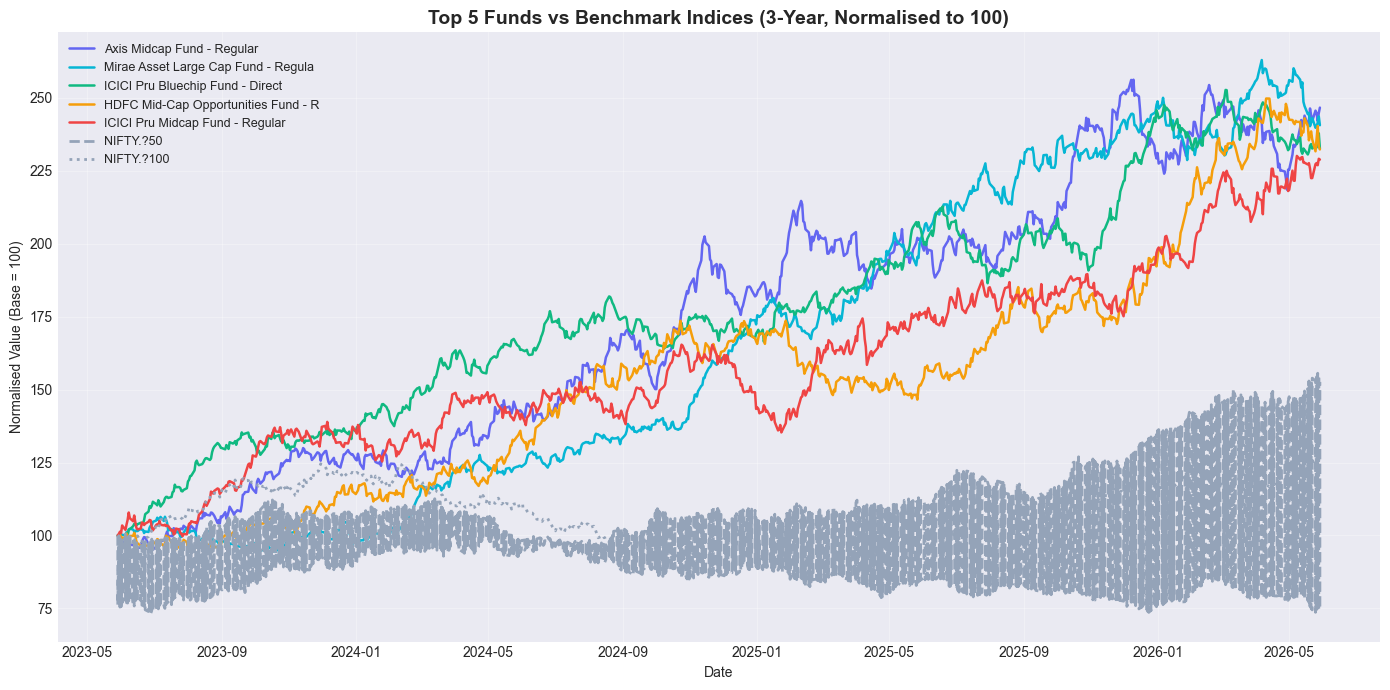

    Saved charts/benchmark_comparison.png


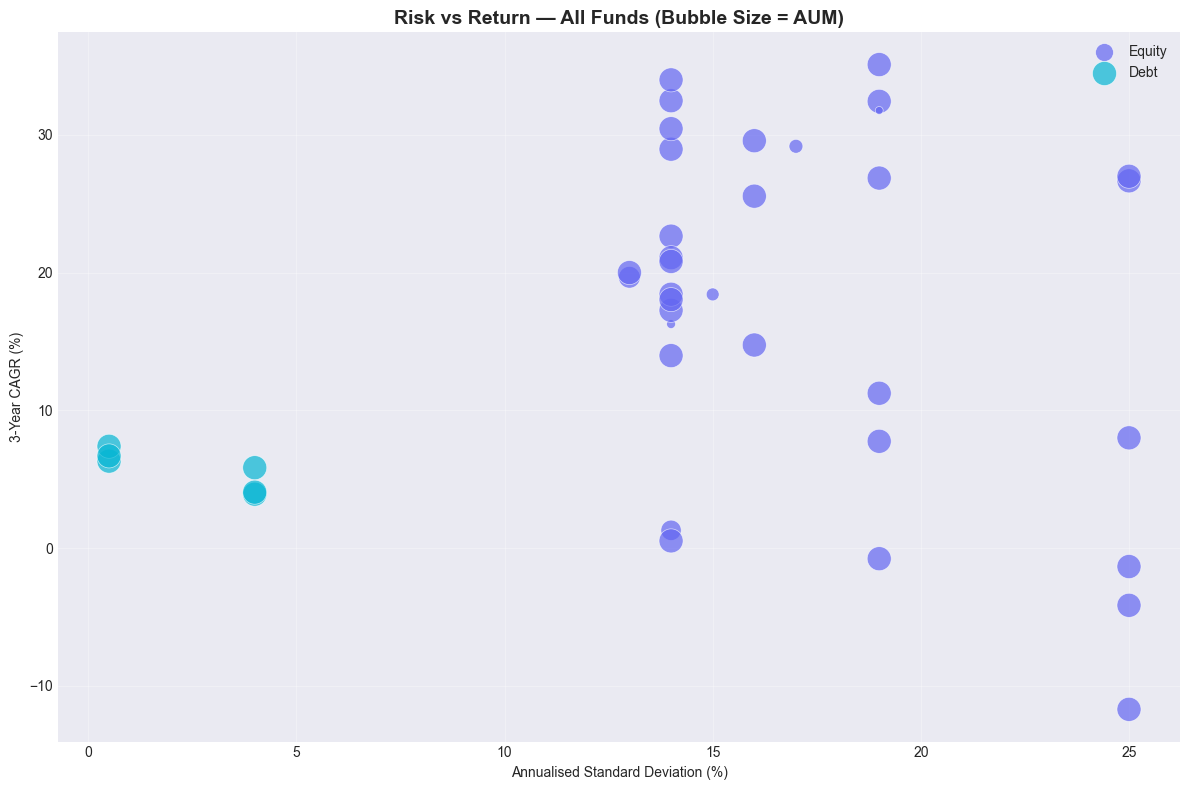

    Saved charts/risk_return_scatter.png

PERFORMANCE METRICS SUMMARY
  ICICI Pru Midcap Fund - Regular - Growth | Score:  84.5 | 3yr CAGR:  31.77% | Sharpe:  1.19
  Axis Midcap Fund - Regular - Growth      | Score:  80.8 | 3yr CAGR:  35.10% | Sharpe:  1.01
  HDFC Mid-Cap Opportunities Fund - Regula | Score:  80.5 | 3yr CAGR:  32.43% | Sharpe:  1.10
  Mirae Asset Large Cap Fund - Regular - G | Score:  80.0 | 3yr CAGR:  33.99% | Sharpe:  1.46
  Kotak Flexicap Fund - Regular - Growth   | Score:  78.2 | 3yr CAGR:  29.58% | Sharpe:  1.32

D4 Complete!
Function main defined successfully.


In [12]:
def main():
    print("=" * 60)
    print("D4: FUND PERFORMANCE METRICS")
    print("=" * 60)

    nav, fund_master, bench, perf = load_data()
    nav = compute_daily_returns(nav)

    # Compute all metrics
    cagr_df = compute_cagr(nav, fund_master)
    sharpe_df = compute_sharpe(nav)
    sortino_df = compute_sortino(nav)
    ab_df = compute_alpha_beta(nav, bench)
    dd_df = compute_max_drawdown(nav)

    # Merge all metrics
    metrics = cagr_df.copy()
    metrics = metrics.merge(sharpe_df, on='amfi_code', how='left')
    metrics = metrics.merge(sortino_df, on='amfi_code', how='left')
    metrics = metrics.merge(ab_df, on='amfi_code', how='left')
    metrics = metrics.merge(dd_df, on='amfi_code', how='left')

    # Add expense ratio and AUM from fund master / performance
    fm_cols = fund_master[['amfi_code', 'expense_ratio_pct', 'risk_category']].copy()
    metrics = metrics.merge(fm_cols, on='amfi_code', how='left')
    perf_cols = perf[['amfi_code', 'aum_crore', 'std_dev_ann_pct', 'morningstar_rating']].copy()
    metrics = metrics.merge(perf_cols, on='amfi_code', how='left')

    # Build scorecard
    scorecard = build_scorecard(metrics)

    # Save outputs
    returns_nav = nav[['amfi_code', 'date', 'nav', 'daily_return']].copy()
    returns_nav.to_csv(PROCESSED / 'returns_computed.csv', index=False)
    print(f"  Saved data/processed/returns_computed.csv ({len(returns_nav)} rows)")

    cagr_df.to_csv(PROCESSED / 'cagr_report.csv', index=False)
    print(f"  Saved data/processed/cagr_report.csv ({len(cagr_df)} rows)")

    ab_df.to_csv(PROCESSED / 'alpha_beta.csv', index=False)
    print(f"  Saved data/processed/alpha_beta.csv ({len(ab_df)} rows)")

    # Save scorecard
    score_cols = ['amfi_code', 'scheme_name', 'fund_house', 'category',
                  'cagr_1yr', 'cagr_3yr', 'cagr_5yr',
                  'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta',
                  'max_drawdown_pct', 'expense_ratio_pct', 'aum_crore',
                  'std_dev_ann_pct', 'morningstar_rating', 'risk_category',
                  'composite_score']
    score_cols = [c for c in score_cols if c in scorecard.columns]
    scorecard[score_cols].to_csv(PROCESSED / 'fund_scorecard.csv', index=False)
    print(f"  Saved data/processed/fund_scorecard.csv ({len(scorecard)} rows)")

    # Generate charts
    generate_charts(nav, bench, scorecard, fund_master)

    # Print summary
    print("\n" + "=" * 60)
    print("PERFORMANCE METRICS SUMMARY")
    print("=" * 60)
    top5 = scorecard.nlargest(5, 'composite_score')
    for _, row in top5.iterrows():
        name = str(row.get('scheme_name', ''))[:40]
        print(f"  {name:<40s} | Score: {row['composite_score']:5.1f} | "
              f"3yr CAGR: {row.get('cagr_3yr', 0):6.2f}% | Sharpe: {row.get('sharpe_ratio', 0):5.2f}")

    print("\nD4 Complete!")


if __name__ == '__main__':
    main()

print('Function main defined successfully.')
